# EDA — PBC Barcelona

**Nguồn**: Mendeley Data (Acevedo et al., Hospital Clinic Barcelona) — người dùng tự tải tay.

**Nội dung**: `Data/images/pbc_barcelona/PBC_dataset_normal_DIB/` — 17.093 ảnh JPG (360×363px, CellaVision DM96), 8 lớp tế bào máu **khỏe mạnh**: basophil, eosinophil, erythroblast, ig, lymphocyte, monocyte, neutrophil, platelet.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

plt.rcParams['figure.figsize'] = (10, 5)
ROOT = Path(r'D:\AI_08_V1\Data\images\pbc_barcelona\PBC_dataset_normal_DIB')

counts = {d.name: len(list(d.glob('*.jpg'))) for d in sorted(ROOT.iterdir()) if d.is_dir()}
counts = pd.Series(counts).sort_values(ascending=False)
print('Tổng số ảnh:', counts.sum())
print(f'Tỷ lệ mất cân bằng (max/min): {counts.max()/counts.min():.1f} lần')
counts

Tổng số ảnh: 17092
Tỷ lệ mất cân bằng (max/min): 2.7 lần


neutrophil      3329
eosinophil      3117
ig              2895
platelet        2348
erythroblast    1551
monocyte        1420
basophil        1218
lymphocyte      1214
dtype: int64

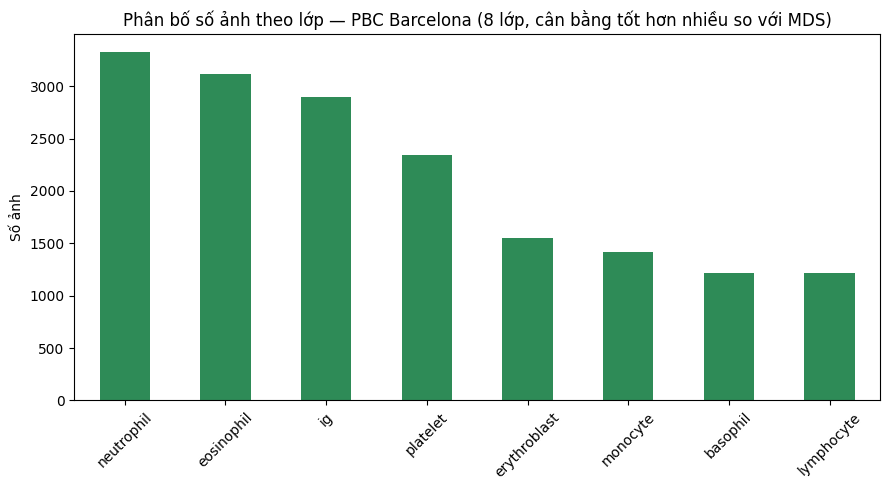

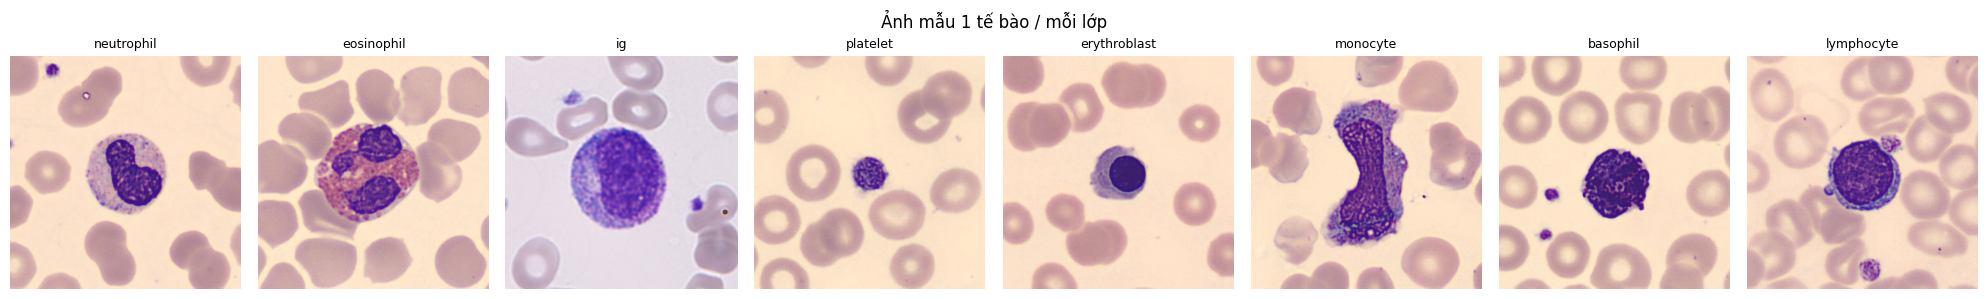

In [2]:
# Biểu đồ phân bố + so sánh trực quan với MDS Bone Marrow (2.7x vs 3958x)
fig, ax = plt.subplots(figsize=(9, 5))
counts.plot.bar(ax=ax, color='seagreen')
ax.set_title('Phân bố số ảnh theo lớp — PBC Barcelona (8 lớp, cân bằng tốt hơn nhiều so với MDS)')
ax.set_ylabel('Số ảnh')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Ảnh mẫu từng lớp (loại bỏ file ẩn/rác nếu có, VD .DS_Store artifact)
fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for ax, cls in zip(axes, counts.index):
    valid_files = (f for f in (ROOT / cls).glob('*.jpg') if not f.name.startswith('.'))
    sample_file = next(valid_files)
    img = Image.open(sample_file)
    ax.imshow(img)
    ax.set_title(cls, fontsize=9)
    ax.axis('off')
plt.suptitle('Ảnh mẫu 1 tế bào / mỗi lớp')
plt.tight_layout()
plt.show()

## Nhận xét

- Mức mất cân bằng chỉ ~2.7 lần (neutrophil 3.330 vs lymphocyte 1.214) — cân bằng tốt hơn hẳn MDS Bone Marrow (3.958 lần), phù hợp làm dữ liệu train/pretrain phân loại bạch cầu.
- Toàn bộ mẫu từ người **khỏe mạnh** — chỉ dùng để nhận diện loại tế bào nền, **không dùng để phát hiện bất thường/bệnh lý**.
- Gán nhãn bởi bác sĩ giải phẫu bệnh chuyên khoa — độ tin cậy nhãn cao.